# IMT 573 - Problem Set 2 - Exploring Data

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

5. Partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are *strongly* encouraged to attempt each question and document their reasoning process even if they cannot find the correct answer. 

6. After completing the assignment, ensure that your code can run from start to finish without issue. Restart the kernal and run all cells to double check.

Name: Andrea Rocha

Collaborators: N/A

For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [1]:
import pandas as pd
import seaborn as sns

In this problem set, we will use data on animals at shelters in the city of [Long Beach, California](https://en.wikipedia.org/wiki/Long_Beach,\_California). The data can be found in the `animal_intakes_and_outcomes.csv` file. You can find more information on this data [here](https://web.archive.org/web/20230929001208/https://data.longbeach.gov/explore/dataset/animal-shelter-intakes-and-outcomes/information/?disjunctive.animal_type&disjunctive.primary_color&disjunctive.sex&disjunctive.intake_cond&disjunctive.intake_type&disjunctive.reason&disjunctive.outcome_type&disjunctive.outcome_subtype&disjunctive.intake_is_dead&disjunctive.outcome_is_dead).

### Problem 1: Inspecting animal shelter data

Load the data and describe in a short paragraph what the data contains and what each variable represents. Perform a basic inspection of the data and discuss what you find.

#### Dataset schema

|Data|Description|Column Name|Type|Sample|
|---|---|---|---|---|
|Animal ID   |Unique identification for each animal   |animal_id   |text   |A002500   |
|Animal Name   |Name of the animal (blank value means name not known). Animals with "\*" are given by shelter staff.    |animal_name   |text   |PENELOPE   |
|Animal Type |Species name of the animal   |animal_type   |text   |DOG   |
|Primary Color |The predominant color of the animal   |primary_color   |text   |WHITE   |
|Secondary Color |Additional coloring, less predominant than the primary color   |secondary_color   |text   |   |
|Sex   |Altered sex of the animal   |sex   |text   |Spayed   |
|DOB  |Date of Birth (if blank, DOB unknown)   |dob   |date   |2008-12-09   |
|Age   |Current age of animal (0 if less than 1 year)   |age   |decimal   |14   |
|Intake Date   |Date on which animal was brought to the shelter    |intake_date   |date   |2017-07-02   |
|Intake Condition   |Condition of animal at intake   |intake_cond   |text   |NORMAL   |
|Intake Type   |The reason for intake such as stray capture, wildlife captures, adopted but returned, owner surrendered etc.   |intake_type   |text   |CONFISCATE   |
|Intake Subtype   |The method or secondary manner in which the animal was admitted to the shelter   |intake_subtype   |text   |POLICE   |
|Reason for Intake   |The reason an owner surrendered their animal   |reason   |text   |   |
|Outcome Date   |Exit or outcome date such as date of adoption or date animal died   |outcome_date   |date   |2017-07-03   |
|Crossing   |Intersection/Cross street of intake or capture   |crossing   |text   |4600 E OCEAN BLVD, LONG BEACH, CA 90803   |
|Jurisdiction   |Geographical jurisdiction of where an animal originated   |jurisdiction   |text   |LONG BEACH   |
|Outcome Type  |Outcome associated with animal - adopted, died, euthanized etc.    |outcome_type   |text   |RETURN TO OWNER   |
|Outcome Subtype   |Secondary manner in which the animal left the shelter, usually used to identify which program, group, or other data useful in measuring program efficiency   |outcome_subtype   |text   |FRE RID HM   |
|intake_is_dead   |No description available for this field   |intake_is_dead   |text   |Alive on intake   |
|outcome_is_dead   |No description available for this field  |outcome_is_dead   |text   |FALSE   |
|was_outcome_alive   |No description available for this field   |was_outcome_alive   |integer   |1   |

In [20]:
animal_df = pd.read_csv('animal-shelter-intakes-and-outcomes.csv')
print(animal_df.head(50))

   Animal ID   Animal Name Animal Type Primary Color Secondary Color  \
0    A002500      PENELOPE         DOG         WHITE             NaN   
1    A226033        SNOOPY         DOG         WHITE             NaN   
2    A234250          NINA         DOG    BR BRINDLE             NaN   
3    A238953          CECE         DOG          BUFF             NaN   
4    A242600         BARBY         DOG         BLACK             NaN   
5    A279626          LANE         DOG         BROWN             NaN   
6    A282135       WHISKEY         DOG         WHITE             NaN   
7    A285440         CHUIE         DOG         BROWN             NaN   
8    A287459       PADFOOT         DOG         BLACK             NaN   
9    A291709      COCO JR.         DOG         BROWN             NaN   
10   A295628        *SASSY         DOG           TAN             NaN   
11   A306874        GUNNER         DOG      TRICOLOR             NaN   
12   A313314        COOPER         DOG         CREAM            

In [14]:
print(animal_df.dtypes)

Animal ID             object
Animal Name           object
Animal Type           object
Primary Color         object
Secondary Color       object
Sex                   object
DOB                   object
Age                  float64
Intake Date           object
Intake Condition      object
Intake Type           object
Intake Subtype        object
Reason for Intake     object
Outcome Date          object
Crossing              object
Jurisdiction          object
Outcome Type          object
Outcome Subtype       object
intake_is_dead        object
outcome_is_dead         bool
was_outcome_alive      int64
dtype: object


In [19]:
animal_df.shape

(39886, 21)

After opening and reading the first 50 lines of data from the animal shelter data set, along with information from the data schema above, I am able to understand that this data set contains a deep dive of information on cats and dogs from animal shelters specifically from the city of Long Beach in California. This data set assigns a unique animal ID to each animal and contains their demographic information (such as sex, color, and age), along with where the pet was found and their condition. Doing a basic inspection of the data, I can see that a majority of these animals that have been found are older in age and often get returned to their owner. 

### Problem 2: Formulating questions

Formulate two motivating questions based on the animal shelter data that you want to explore. Describe why these questions are interesting and how you might go about answering them.

Question 1: From this data set, I would like to compare the count of how many dogs vs cat end up at the animal shelters in Long Beach and their outcome type. This question is interesting because it is commonly known for cats to be inside/outside pets and wander around and eventually make it back to their owners, but not for dogs. Dogs usually are homebound and if there are dogs in the streets, they are either stray and always have been, have been abandoned, or other circumstances and it would be interesting to explore the ratio of how many dogs vs cats end up making it back home or not.

Question 2: Another interesting question would be how many of these animals that end up at the shelterer injured end up making it out alive as well and how old the animal is. This question is interesting because I know that there are many animal lovers whom work and volunteer at shelters to help animals, especially if they are injured. 

### Problem 3: Exploring data

For each of the questions you proposed in Problem 2, perform an exploratory data analysis designed to address the question. At a minimum, you should produce two visualizations related to each question. Be sure to describe what the visuals show and how they speak to your question of interest.

In [21]:
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

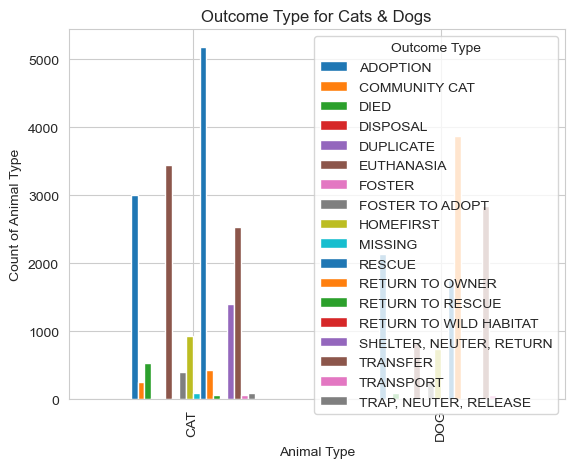

In [34]:
cats_and_dogs = animal_df[animal_df['Animal Type'].isin(['CAT', 'DOG'])]
cats_and_dogs.groupby(['Animal Type', 'Outcome Type']).size().unstack().plot(kind= 'bar')
plt.ylabel('Count of Animal Type')
plt.title('Outcome Type for Cats & Dogs')
plt.legend(title='Outcome Type', loc='upper right')
plt.show()

After creating my first visualization to answer my first question, my visulization shows the counts for the different outcome types that have been tagged from this data set. I was sad to see that there is quite a number of cats and simalarly dogs, that get euthanized. I was not surprised to see that more cats are adopted whereas dogs get returned back to their owners. There seems to be a higher count of cats than dogs based on my visualization and though it makes sense, I was a little surprised from the results because of how many dogs were in the first 50 rows of the data set.

Text(0.5, 1.0, 'Age & Intake Condition of Animal & Their Outcome')

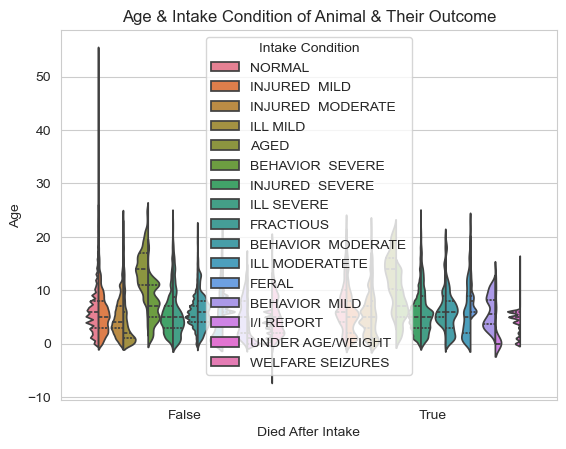

In [40]:
sns.violinplot(data=animal_df, x='outcome_is_dead', y='Age', hue='Intake Condition', split='True', bw_adjust=.5, inner='quart')
plt.ylabel('Age')
plt.xlabel('Died After Intake')
plt.title('Age & Intake Condition of Animal & Their Outcome')

### Problem 4: Challenge your results

After completing the exploratory analyses from Problem 3, do you have any concerns about your findings? How well defined was your original question? Do you still believe this question can be answered using this dataset? Comment on any ethical and/or privacy concerns you have with your analysis.

After completing my exploratory analyses from problem 3, my first concern was how the legend in my first bar visualization did not move to the upper right and made the 'dog' section very hard to see. Another issue I noticed right away, was that in the legend, because there was a variety of different outcome types, the colors in the legend repeat. This comes off as confusing because how would you know which outcome is aligned to which bar. Also, looking back at my question, it is worded more so in seeing the count of dogs vs cats. While you get an idea of more so count by dog vs cat it doesn't explicilty show the count, the data more so shows count of outcome types by cats & dogs. 

Experiencing also the same issue with my legend being in the center of the graph, it makes it hard to get a clear view of the results. Something that is concerning to me is how the 'True' & 'False' is split it. Does everything that is far right considered true and same for the opposite? It is also hard to really tell the true intake condition of the animal given that there are many options and the colors end up getting morphed. I do think that this data set can answer the questions I have posed and more, but with better visualizations. Some ethical concerns that would come up based on this question would be why are there some animals that did die after intake when their condiiton was 'normal'?